### Remap geothermal dataset (Davies, 2013) to tx2_3

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf, intake
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
fname = '../mesh/tx1_12_grid_260213.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l'})
ds_out

<xarray.Dataset>
Dimensions:  (yh: 480, xh: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 ...
    lat      (yh, xh) float64 ...
    ulon     (yh, nxp) float64 ...
    ulat     (yh, nxp) float64 ...
    vlon     (nyp, xh) float64 ...
    vlat     (nyp, xh) float64 ...
    ...       ...
    tarea    (yh, xh) float64 ...
    tmask    (yh, xh) float64 ...
    angle    (yh, xh) float64 ...
    z_l      (yh, xh) float64 ...
    ar       (yh, xh) float64 ...
    egs      (yh, xh) float64 ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2023-04-14T10:43:08.113626
    type:         Glogal 2/3 degree grid file

In [4]:
infile = '/glade/campaign/cgd/oce/datasets/obs/geothermal/geothermal_davies2013_ncar.nc'
ds_in = xr.open_dataset(infile).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b'})
ds_in

<xarray.Dataset>
Dimensions:        (yh: 1080, xh: 1440, yq: 1081, xq: 1441)
Coordinates:
  * yh             (yh) float32 0.5 1.5 2.5 3.5 ... 1.078e+03 1.078e+03 1.08e+03
  * xh             (xh) float32 0.5 1.5 2.5 3.5 ... 1.438e+03 1.438e+03 1.44e+03
Dimensions without coordinates: yq, xq
Data variables:
    geothermal_hf  (yh, xh) float32 ...
    lat            (yh, xh) float64 ...
    lon            (yh, xh) float64 ...
    lat_b          (yq, xq) float64 ...
    lon_b          (yq, xq) float64 ...
Attributes:
    title:          Geothermal heat flow from Davies, 2013, re-gridded to OM4...
    reference:      Davies, J. Huw, 2013: Global map of solid Earth surface h...
    reference_url:  http://dx.doi.org/10.1002/ggge.20271

In [5]:
def regrid_tracer(fld, ds_in, ds_out, method='conservative'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])
    return fld_out

#### Potential temperature

In [6]:
geothermal_hf = regrid_tracer('geothermal_hf', ds_in, ds_out)
geothermal_hf

<xarray.DataArray (yh: 480, xh: 540)>
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.05298106, 0.05332395, 0.05414148, ..., 0.05428809, 0.05358988,
        0.05329704],
       [0.05306507, 0.05335549, 0.05416296, ..., 0.05430644, 0.05361681,
        0.05336878],
       [0.0530719 , 0.05337847, 0.05417501, ..., 0.05431673, 0.05363644,
        0.05337462]], dtype=float32)
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  conservative

In [7]:
geothermal_hf = geothermal_hf.rename('geothermal_hf')

##### Visual inspection
Make sure original and remapped plots look similar.

Text(0.5, 0.98, 'geothermal_hf')

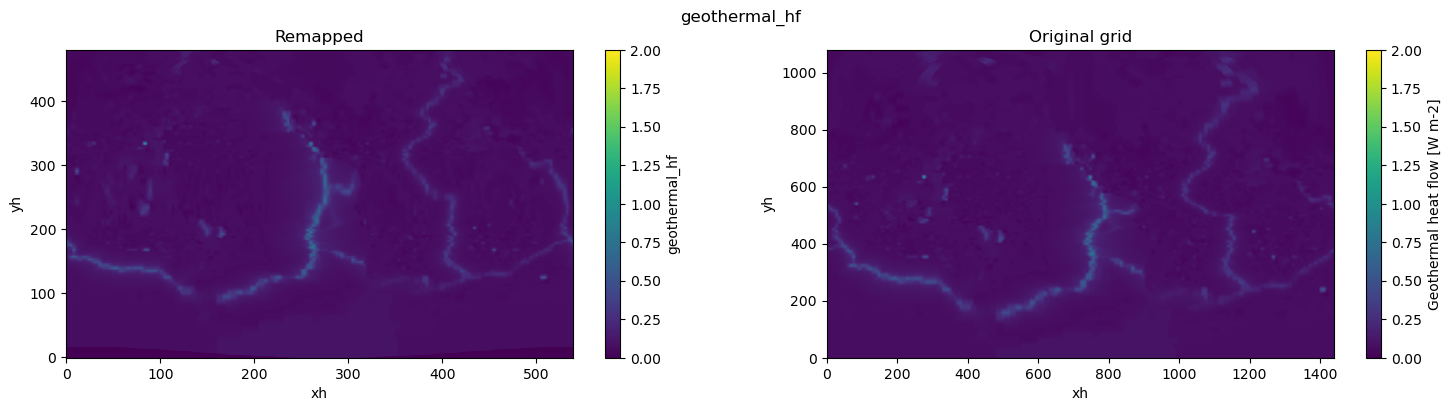

In [8]:
# visual inspection. Make sure original and remapped plots look similar
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
geothermal_hf.plot.pcolormesh(ax=axes[0], vmin=0,vmax=2)
ds_in['geothermal_hf'].plot.pcolormesh(ax=axes[1], vmin=0,vmax=2)
axes[0].set_title('Remapped')
axes[1].set_title('Original grid')
plt.suptitle('geothermal_hf')

In [9]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')
data

<xarray.DataArray 'geothermal_hf' (yh: 480, xh: 540)>
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.05298106, 0.05332395, 0.05414148, ..., 0.05428809, 0.05358988,
        0.05329704],
       [0.05306507, 0.05335549, 0.05416296, ..., 0.05430644, 0.05361681,
        0.05336878],
       [0.0530719 , 0.05337847, 0.05417501, ..., 0.05431673, 0.05363644,
        0.05337462]], dtype=float32)
Dimensions without coordinates: yh, xh

In [10]:
data

<xarray.DataArray 'geothermal_hf' (yh: 480, xh: 540)>
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.05298106, 0.05332395, 0.05414148, ..., 0.05428809, 0.05358988,
        0.05329704],
       [0.05306507, 0.05335549, 0.05416296, ..., 0.05430644, 0.05361681,
        0.05336878],
       [0.0530719 , 0.05337847, 0.05417501, ..., 0.05431673, 0.05363644,
        0.05337462]], dtype=float32)
Dimensions without coordinates: yh, xh

In [11]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')

# Global attrs
data.attrs['long_name'] = 'Geothermal heat flow'
data.attrs['standard_name'] = 'upward_geothermal_heat_flux_at_sea_floor'
data.attrs['units'] = 'W m-2'
data.attrs['cell_methods'] = 'area: mean'

# Create a dataset and add the DataArray to it
dataset = xr.Dataset({'geothermal_hf': data})

dataset.attrs['description'] = 'Geothermal heat flow from Davies, 2013, re-gridded to tx1_12'
dataset.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
dataset.attrs['date'] = datetime.now().isoformat()
dataset.attrs['infile'] = infile
dataset.attrs['url'] = 'https://github.com/NCAR/tx1_12/geothermal'
# save
fname = 'geothermal_davies2013_tx1_12_{}{}{}.nc'.format(datetime.now().isoformat()[0:4],datetime.now().isoformat()[5:7],
       datetime.now().isoformat()[8:10])

dataset.to_netcdf(fname, encoding={'geothermal_hf': {'_FillValue': None}})

In [ ]:
# TODO
# !nccopy -k cdf5 energy_new_tx2_3_conserve_260213.nc energy_new_tx2_3_conserve_260213_cdf5.nc